c:\Users\KIIT\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


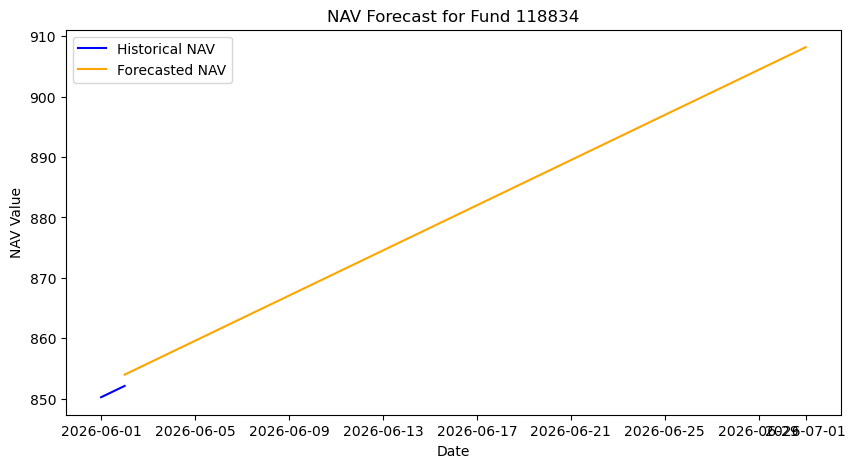

Model Performance — MSE: 0.0000, R²: 1.0000


In [1]:
# Bluestock MF Capstone — Day 6: Advanced Analytics
# Author: Ayush Kumar Singh
# Date: 12 June 2026

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path

DATA_DIR = Path("../data/processed")

# -----------------------------
# 1️⃣ Load NAV history
# -----------------------------
nav_history = pd.read_csv(DATA_DIR / "nav_history_clean.csv")
nav_history["nav_date"] = pd.to_datetime(nav_history["nav_date"])
nav_history = nav_history.sort_values(["amfi_code","nav_date"])

# -----------------------------
# 2️⃣ Prepare data for forecasting
# -----------------------------
fund_code = nav_history["amfi_code"].unique()[0]  # pick first fund
fund_data = nav_history[nav_history["amfi_code"] == fund_code].copy()
fund_data["day_index"] = np.arange(len(fund_data))

X = fund_data[["day_index"]]
y = fund_data["nav_value"]

# -----------------------------
# 3️⃣ Train linear regression model
# -----------------------------
model = LinearRegression()
model.fit(X, y)

# Predict next 30 days
future_days = np.arange(len(fund_data), len(fund_data)+30).reshape(-1,1)
future_preds = model.predict(future_days)

# -----------------------------
# 4️⃣ Plot NAV forecast
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(fund_data["nav_date"], y, label="Historical NAV", color="blue")
plt.plot(pd.date_range(fund_data["nav_date"].iloc[-1], periods=30, freq="D"), future_preds, label="Forecasted NAV", color="orange")
plt.title(f"NAV Forecast for Fund {fund_code}")
plt.xlabel("Date")
plt.ylabel("NAV Value")
plt.legend()
plt.show()

# -----------------------------
# 5️⃣ Evaluate model
# -----------------------------
preds = model.predict(X)
mse = mean_squared_error(y, preds)
r2 = r2_score(y, preds)
print(f"Model Performance — MSE: {mse:.4f}, R²: {r2:.4f}")

# -----------------------------
# 6️⃣ SIP Forecast (if transactions exist)
# -----------------------------
txn_path = DATA_DIR / "cleaned_nav_history.csv"
if txn_path.exists():
    transactions = pd.read_csv(txn_path)
    if "date" in transactions.columns and "amount" in transactions.columns:
        transactions["date"] = pd.to_datetime(transactions["date"], errors="coerce")
        sip_txn = transactions[transactions["transaction_type"].str.lower() == "sip"]
        sip_monthly = sip_txn.groupby(sip_txn["date"].dt.to_period("M"))["amount"].sum().reset_index()
        sip_monthly["month_index"] = np.arange(len(sip_monthly))
        X_sip = sip_monthly[["month_index"]]
        y_sip = sip_monthly["amount"]

        sip_model = LinearRegression()
        sip_model.fit(X_sip, y_sip)
        future_months = np.arange(len(sip_monthly), len(sip_monthly)+6).reshape(-1,1)
        future_sip = sip_model.predict(future_months)

        plt.figure(figsize=(8,4))
        plt.plot(sip_monthly["month_index"], y_sip, label="Historical SIP Inflows", color="green")
        plt.plot(future_months, future_sip, label="Forecasted SIP Inflows", color="red")
        plt.title("SIP Inflow Forecast (Next 6 Months)")
        plt.xlabel("Month Index")
        plt.ylabel("Amount")
        plt.legend()
        plt.show()
